In [1]:
import os
from os.path import join
from pathlib import Path
import pandas as pd
import xarray as xr
import shapely.geometry
from typing import Tuple, Union, List
import logging
from pathlib import Path

import sys
project_root = Path('/Users/zmhoppinen/Documents/spicy-snow/').resolve()
sys.path.insert(0, str(project_root))

# import functions for downloading
from spicy_snow.find_data import get_sentinel1_urls, find_snowcover_urls
from spicy_snow.processing.generate_dataarrays import generate_sentinel1_dataarray,\
    generate_snowcover_dataarray, generate_forest_fraction_dataarray, convert_snowcover_dates_to_s1_overpasses

# import functions for pre-processing
from spicy_snow.processing.s1_preprocessing import s1_orbit_averaging, s1_clip_outliers, ims_water_mask, amplitude_to_dB

# import the functions for snow_index calculation
from spicy_snow.processing.snow_index import calc_delta_vv, calc_delta_cross_ratio, \
    calc_delta_gamma, clip_delta_gamma_outlier, calc_snow_index, calc_snow_index_to_snow_depth

# import the functions for wet snow flag
from spicy_snow.processing.wet_snow import id_newly_frozen_snow, id_newly_wet_snow, \
    id_wet_negative_si, flag_wet_snow

# setup root logger
from spicy_snow.utils.spicy_logging import setup_logging
from spicy_snow.utils.checks import validate_aoi, validate_dates
from spicy_snow.utils.download import download_urls, download_urls_parallel


In [2]:
test_start_date = '2020-10-01'
test_stop_date = '2021-05-01'
dates = [test_start_date, test_stop_date]
# test_aoi = [-114.5, 43, -114, 44]


# test point retrieval

In [ ]:
aoi = (-114.2, 43.75)

# -- preflight checks -- #
dates = validate_dates(*dates)
debug = False
ims_masking = True,
wet_snow_thresh = -2
freezing_snow_thresh = 1
wet_SI_thresh = 0
outfp = None
A, B, C = [2.5, 0.2, 0.55]
work_stem = None
work_dir = Path('/Users/zmhoppinen/Documents/spicy-snow/local')
resolution = 1000

aoi = validate_aoi(aoi)

from shapely.geometry import Point
point = True if isinstance(aoi, Point) else False
# get sentinel 1 data search results
s1_urls = get_sentinel1_urls(start_date = dates[0], stop_date = dates[1], aoi = aoi)
# Keep only necessary downloads vv, vh, mask.
# s1_urls = [u for u in s1_urls if u.endswith(('_VV.tif', '_VH.tif', '_mask.tif'))]
# download sentinel urls
s1_fps = download_urls_parallel(s1_urls, work_dir.joinpath('opera'))

# generate dataset and start to save s1 data vars. Use zarr to reduce memory load for big arrays
ds = xr.Dataset()
ds['vv'] = generate_sentinel1_dataarray(s1_fps, aoi, pol = 'VV', resolution=resolution)

# grab spatial reference from first time step of VV
spatial_reference = ds['vv'].isel(time = 0)

# repeat combining and spatial resampling for VH
ds['vh'] = generate_sentinel1_dataarray(s1_fps, aoi, pol = 'VH', ref = spatial_reference, resolution=resolution)

# next VIIRS snowcover #
# log.info("Downloading VIIRS snowcover data")

# download viirs snow cover fraction for each sentinel 1 overpass date
snowcover_urls = find_snowcover_urls(start_date = dates[0], stop_date = dates[1], date_list = ds.time.dt.date, aoi = aoi)
snowcover_fps = download_urls_parallel(snowcover_urls, work_dir.joinpath('snowcover'))

# generate snow cover dataset
viirs_snowcover = generate_snowcover_dataarray(snowcover_fps, ref = spatial_reference)

# resample date times from each day to the exact s1 overpass time. Doubles if two in one day
viirs_snowcover = convert_snowcover_dates_to_s1_overpasses(viirs_snowcover, ds['vv'])

# grab out watermask information and snowcover data
# table 1 https://nsidc.org/sites/default/files/documents/user-guide/multi_vnp10a1f-v002-userguide.pdf
ds['watermask'] = (viirs_snowcover == 237).median('time')
# set pixels with over 10% snow cover to snowcovered
ds['snowcover'] = (viirs_snowcover.where(viirs_snowcover <= 100) > 10).astype(int)

# finally NLCD or Proba-V forest cover fraction #
# log.info("Downloading forest cover fraction data")
# download fcf and add to dataset ['fcf'] keyword
# this will us NLCD for within US (very fast) or Proba-v for global (very slow)
ds['fcf'] = generate_forest_fraction_dataarray(aoi, ref = spatial_reference)

# -- Preprocessing Sentinel-1 backscatter -- #
# log.info("Preprocessing Sentinel-1 images")

# water mask dataset
ds = ims_water_mask(ds)

# mask out outliers in incidence angle
# no longer used. Using opera's included shadow and layover mask generate_dataset
# ds = s1_incidence_angle_masking(ds)

# convert from gamma0 amplitude to dB
ds = amplitude_to_dB(ds)

# average orbits backscatter to same means
ds = s1_orbit_averaging(ds)
# clip outlier values of backscatter to overall mean
ds = s1_clip_outliers(ds)

# -- Calulating Snow Index -- #
# log.info("Calculating snow index")
# calculate delta CR and delta VV
ds = calc_delta_cross_ratio(ds, A = A)
ds = calc_delta_vv(ds)

# calculate delta gamma with delta CR and delta VV with FCF
ds = calc_delta_gamma(ds, B = B)

# clip outliers of delta gamma
ds = clip_delta_gamma_outlier(ds)

# calculate snow_index from delta_gamma
ds = calc_snow_index(ds, ims_masking = ims_masking)

# convert snow index to snow depth
ds = calc_snow_index_to_snow_depth(ds, C = C)

## Wet Snow Flags
# log.info("Flag wet snow")
# find newly wet snow
ds = id_newly_wet_snow(ds, wet_thresh = wet_snow_thresh)
ds = id_wet_negative_si(ds, wet_SI_thresh = wet_SI_thresh)

# find newly frozen snow
ds = id_newly_frozen_snow(ds, freeze_thresh = freezing_snow_thresh)

# make wet_snow flag
ds = flag_wet_snow(ds)

ds.attrs['param_A'] = A
ds.attrs['param_B'] = B
ds.attrs['param_C'] = C

ds.attrs['bounds'] = aoi.bounds

# set dimensions in rioxarray order
ds = ds.transpose("time", "y", "x")

if outfp:
    outfp = str(outfp)
    
    ds.to_netcdf(outfp)


(spicy-snow asf_search INFO) SEARCH: Using search opts {
    "intersectsWith": "POINT (-114.2000000000000028 43.7500000000000000)",
    "platform": [
        "SENTINEL-1C",
        "SENTINEL-1A",
        "SENTINEL-1B"
    ],
    "processingLevel": [
        "RTC"
    ],
    "start": "2020-10-01T00:00:00Z",
    "end": "2021-05-01T00:00:00Z"
}
(spicy-snow asf_search INFO) SEARCH: Using cmr endpoint: "https://cmr.earthdata.nasa.gov/search/granules.umm_json"
(spicy-snow asf_search INFO) SUBQUERY 1: Beginning subquery with opts: {
    "intersectsWith": "POINT (-114.2000000000000028 43.7500000000000000)",
    "start": "2020-10-01T00:00:00Z",
    "end": "2021-05-01T00:00:00Z",
    "collections": [
        "C1259974840-ASF",
        "C1260721853-ASF",
        "C2777436413-ASF",
        "C2803501097-ASF"
    ]
}
(spicy-snow asf_search INFO) Query Time Elapsed 0.7399110794067383
(spicy-snow asf_search INFO) Page Processing Time 1.1205673217773438e-05
(spicy-snow asf_search INFO) SUBQUERY 1 COMPL

Downloading:   0%|          | 0/258 [00:00<?, ?it/s]

(1000, 1000)


Reprojecting + inserting vv:   0%|          | 0/86 [00:00<?, ?it/s]

(1000, 1000)


Reprojecting + inserting vh:   0%|          | 0/86 [00:00<?, ?it/s]

(spicy-snow earthaccess.api INFO) Granules found: 213


Downloading:   0%|          | 0/86 [00:00<?, ?it/s]

(spicy-snow spicy_snow.processing.generate_dataarrays INFO) AOI inside of CONUS. NLCD 2021 Forest Cover


# test full gridded pipeline

In [5]:
# -- preflight checks -- #
test_aoi = [-114.5, 43, -114, 44]

aoi = validate_aoi(test_aoi)
dates = validate_dates(*dates)
debug = False
ims_masking = True,
wet_snow_thresh = -2
freezing_snow_thresh = 1
wet_SI_thresh = 0
outfp = None
params= [2.5, 0.2, 0.55]
work_stem = None
work_dir = Path('/Users/zmhoppinen/Documents/spicy-snow/local')

assert isinstance(debug, bool), f"Debug keyword must be boolean. Got {debug}"
assert isinstance(params, list) or isinstance(params, tuple), f"param keyword must be list or tuple. Got {type(params)}"
assert len(params) == 3, f"List of params must be 3 in order A, B, C. Got {params}"
A, B, C = params

assert wet_snow_thresh < 0, f"Wet snow threshold set at {wet_snow_thresh}. This value is positive but should be negative."
assert freezing_snow_thresh > 0, f"Refreeze threshold set at {freezing_snow_thresh}. This value is negative but should be positive."

if outfp is not None:
    outfp = Path(outfp).expanduser().resolve()
    assert outfp.parent.exists(), f"Out filepath {outfp}'s directory does not exist"

# -- Setting up directories and logging -- #
work_dir = Path(work_dir)
os.makedirs(work_dir, exist_ok = True)

setup_logging(log_dir = join(work_dir, 'logs'), debug = debug)
log = logging.getLogger(__name__)

# get main stem for automated file naming
work_stem = f'{pd.to_datetime(dates[0]).date()}_{pd.to_datetime(dates[1]).date()}' if work_dir is not None else work_stem

# -- Downloading S1, FCF, Snowcover -- #

# start with Sentinel-1 #
log.info("Downloading sentinel-1 gamma0 backscatter data")

# get sentinel 1 data search results
s1_urls = get_sentinel1_urls(start_date = dates[0], stop_date = dates[1], aoi = aoi)
# Keep only necessary downloads vv, vh, mask.
s1_urls = [u for u in s1_urls if u.endswith(('_VV.tif', '_VH.tif', '_mask.tif'))]
# download sentinel urls
s1_fps = download_urls_parallel(s1_urls, work_dir.joinpath('opera'))

# generate dataset and start to save s1 data vars. Use zarr to reduce memory load for big arrays
ds = xr.Dataset()
ds['vv'] = generate_sentinel1_dataarray(s1_fps, aoi, pol = 'VV')

# grab spatial reference from first time step of VV
spatial_reference = ds['vv'].isel(time = 0)

# repeat combining and spatial resampling for VH
ds['vh'] = generate_sentinel1_dataarray(s1_fps, aoi, pol = 'VH', ref = spatial_reference)

# next VIIRS snowcover #
log.info("Downloading VIIRS snowcover data")

# download viirs snow cover fraction for each sentinel 1 overpass date
snowcover_urls = find_snowcover_urls(start_date = dates[0], stop_date = dates[1], date_list = ds.time.dt.date, aoi = aoi)
snowcover_fps = download_urls_parallel(snowcover_urls, work_dir.joinpath('snowcover'))

# generate snow cover dataset
viirs_snowcover = generate_snowcover_dataarray(snowcover_fps, ref = spatial_reference)

# resample date times from each day to the exact s1 overpass time. Doubles if two in one day
viirs_snowcover = convert_snowcover_dates_to_s1_overpasses(viirs_snowcover, ds['vv'])

# grab out watermask information and snowcover data
# table 1 https://nsidc.org/sites/default/files/documents/user-guide/multi_vnp10a1f-v002-userguide.pdf
ds['watermask'] = (viirs_snowcover == 237).median('time')
# set pixels with over 10% snow cover to snowcovered
ds['snowcover'] = (viirs_snowcover.where(viirs_snowcover <= 100) > 10).astype(int)

# finally NLCD or Proba-V forest cover fraction #
log.info("Downloading forest cover fraction data")
# download fcf and add to dataset ['fcf'] keyword
# this will us NLCD for within US (very fast) or Proba-v for global (very slow)
ds['fcf'] = generate_forest_fraction_dataarray(aoi, ref = spatial_reference)

# -- Preprocessing Sentinel-1 backscatter -- #
log.info("Preprocessing Sentinel-1 images")

# water mask dataset
ds = ims_water_mask(ds)

# mask out outliers in incidence angle
# no longer used. Using opera's included shadow and layover mask generate_dataset
# ds = s1_incidence_angle_masking(ds)

# convert from gamma0 amplitude to dB
ds = amplitude_to_dB(ds)

# average orbits backscatter to same means
ds = s1_orbit_averaging(ds)
# clip outlier values of backscatter to overall mean
ds = s1_clip_outliers(ds)

# -- Calulating Snow Index -- #
log.info("Calculating snow index")
# calculate delta CR and delta VV
ds = calc_delta_cross_ratio(ds, A = A)
ds = calc_delta_vv(ds)

# calculate delta gamma with delta CR and delta VV with FCF
ds = calc_delta_gamma(ds, B = B)

# clip outliers of delta gamma
ds = clip_delta_gamma_outlier(ds)

# calculate snow_index from delta_gamma
ds = calc_snow_index(ds, ims_masking = ims_masking)

# convert snow index to snow depth
ds = calc_snow_index_to_snow_depth(ds, C = C)

## Wet Snow Flags
log.info("Flag wet snow")
# find newly wet snow
ds = id_newly_wet_snow(ds, wet_thresh = wet_snow_thresh)
ds = id_wet_negative_si(ds, wet_SI_thresh = wet_SI_thresh)

# find newly frozen snow
ds = id_newly_frozen_snow(ds, freeze_thresh = freezing_snow_thresh)

# make wet_snow flag
ds = flag_wet_snow(ds)

ds.attrs['param_A'] = A
ds.attrs['param_B'] = B
ds.attrs['param_C'] = C

ds.attrs['bounds'] = aoi.bounds

# set dimensions in rioxarray order
ds = ds.transpose("time", "y", "x")

if outfp:
    outfp = str(outfp)
    
    ds.to_netcdf(outfp)

gridded = ds

(spicy-snow __main__ INFO) Downloading sentinel-1 gamma0 backscatter data
(spicy-snow asf_search INFO) SEARCH: Using search opts {
    "intersectsWith": "POLYGON ((-114.0000000000000000 43.0000000000000000, -114.0000000000000000 44.0000000000000000, -114.5000000000000000 44.0000000000000000, -114.5000000000000000 43.0000000000000000, -114.0000000000000000 43.0000000000000000))",
    "platform": [
        "SENTINEL-1C",
        "SENTINEL-1A",
        "SENTINEL-1B"
    ],
    "processingLevel": [
        "RTC"
    ],
    "start": "2020-10-01T00:00:00Z",
    "end": "2021-05-01T00:00:00Z"
}
(spicy-snow asf_search INFO) SEARCH: Using cmr endpoint: "https://cmr.earthdata.nasa.gov/search/granules.umm_json"
(spicy-snow asf_search INFO) SUBQUERY 1: Beginning subquery with opts: {
    "intersectsWith": "POLYGON ((-114.0000000000000000 43.0000000000000000, -114.0000000000000000 44.0000000000000000, -114.5000000000000000 44.0000000000000000, -114.5000000000000000 43.0000000000000000, -114.00000000

Downloading:   0%|          | 0/2022 [00:00<?, ?it/s]

(100, 100)


Reprojecting + inserting vv:   0%|          | 0/674 [00:00<?, ?it/s]

/Users/zmhoppinen/miniforge3/envs/spicy/lib/python3.13/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


KeyboardInterrupt: 

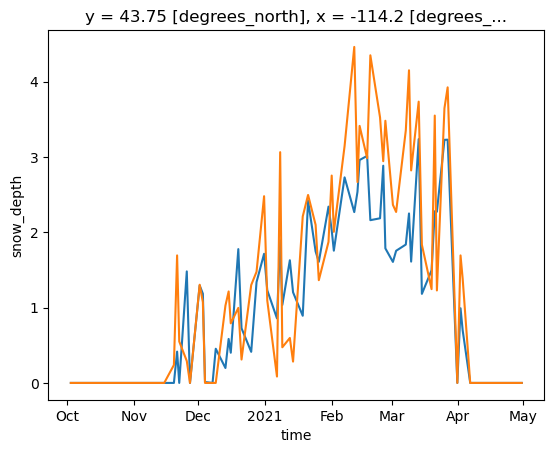

In [ ]:
gridded['snow_depth'].sel(x = -114.2, y = 43.75, method = 'nearest').plot()
import numpy as np
import matplotlib.pyplot as plt
ds['snow_depth'].plot(ax = plt.gca())